# Training mô hình Logistic Regression và tối ưu siêu tham số bằng Optuna Bayesian Optimization

## 1. Import thư viện cần thiết


In [1]:
pip install optuna scikit-learn pandas numpy


Note: you may need to restart the kernel to use updated packages.


In [3]:
import optuna
import numpy as np
import pandas as pd


# 2. Import dữ liệu

In [7]:
df_train = pd.read_csv('../../../Feature Selection /Leads_Selected_Train.csv')
df_test = pd.read_csv('../../../Feature Selection /Leads_Selected_Test.csv')


In [8]:
X_train = df_train.drop('Converted', axis=1)
X_train.columns

y_train = df_train['Converted']


In [9]:
print(X_train.shape, y_train.shape)


(6152, 6) (6152,)


In [10]:
X_test = df_test.drop('Converted', axis=1)
y_test = df_test['Converted']
print(X_test.shape, y_test.shape)


(1538, 6) (1538,)


### Định nghĩa hàm objective cho Optuna để tối ưu siêu tham số của Support Vector Machine (SVM)

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import optuna


In [8]:
def objective(trial):

    # Ưu tiên kernel nhanh và ổn định hơn
    kernel = trial.suggest_categorical(
        "kernel",
        ["linear", "rbf"]
    )

    # Thu hẹp C
    C = trial.suggest_float(
        "C",
        0.1, 20,
        log=True
    )

    params = {
        "C": C,
        "kernel": kernel,
        "random_state": 42
    }

    # Gamma chỉ cần vùng vừa phải
    if kernel == "rbf":
        params["gamma"] = trial.suggest_float(
            "gamma",
            1e-3, 1e-1,
            log=True
        )

    model = SVC(
        **params,
        probability=False   # ROC-AUC vẫn dùng decision_function được
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,               # giảm từ 5 -> 3
        scoring="roc_auc",
        n_jobs=1
    )

    return scores.mean()


In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(),
)
study.optimize(objective, n_trials=100, timeout=120)

print("Best ROC-AUC (CV):", round(study.best_value, 4))
print("Best params (raw) :", study.best_params)


Best ROC-AUC (CV): 0.8684
Best params (raw) : {'kernel': 'rbf', 'C': 19.16465784534573, 'gamma': 0.03756626973385321}


In [12]:
bp     = study.best_params
kernel = bp["kernel"]

best_params = dict(
    C=bp["C"],
    kernel=kernel,
    probability=True,
    random_state=42,
)

if kernel in ["rbf", "poly", "sigmoid"]:
    best_params["gamma"] = bp["gamma"]
if kernel == "poly":
    best_params["degree"] = bp["degree"]
    best_params["coef0"]  = bp["coef0"]
if kernel == "sigmoid":
    best_params["coef0"] = bp["coef0"]

print("Best params (clean):", best_params)

best_model = SVC(**best_params)
best_model.fit(X_train, y_train)


Best params (clean): {'C': 19.16465784534573, 'kernel': 'rbf', 'probability': True, 'random_state': 42, 'gamma': 0.03756626973385321}


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",19.16465784534573
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.03756626973385321
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Test ROC-AUC: 0.8779
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       936
           1       0.78      0.74      0.76       602

    accuracy                           0.82      1538
   macro avg       0.81      0.80      0.81      1538
weighted avg       0.81      0.82      0.82      1538



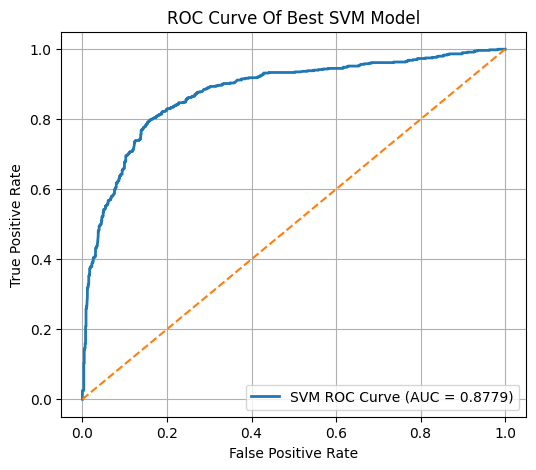

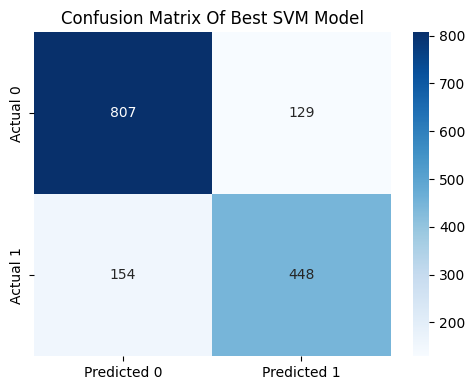

True Negative  (TN): 807
False Positive (FP): 129
False Negative (FN): 154
True Positive  (TP): 448
Precision  : 0.7764
Recall     : 0.7442
F1-Score   : 0.7600
Accuracy   : 0.8160
Specificity: 0.8622


In [13]:
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

# ── Prediction ────────────────────────────────────────────────
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# ── ROC-AUC Score ─────────────────────────────────────────────
auc_score = roc_auc_score(y_test, y_proba)

print("Test ROC-AUC:", round(auc_score, 4))
print(classification_report(y_test, y_pred))

# ── ROC Curve ─────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM ROC Curve (AUC = {auc_score:.4f})"
)

# random classifier line
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Of Best SVM Model")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted 0", "Predicted 1"],
    yticklabels=["Actual 0", "Actual 1"],
    ax=ax,
)

ax.set_title("Confusion Matrix Of Best SVM Model")

plt.tight_layout()
plt.show()

# ── Metrics ───────────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()

print(f"True Negative  (TN): {tn}")
print(f"False Positive (FP): {fp}")
print(f"False Negative (FN): {fn}")
print(f"True Positive  (TP): {tp}")

print(f"Precision  : {tp / (tp + fp):.4f}")
print(f"Recall     : {tp / (tp + fn):.4f}")
print(f"F1-Score   : {2 * (tp / (tp + fp)) * (tp / (tp + fn)) / ((tp / (tp + fp)) + (tp / (tp + fn))):.4f}")
print(f"Accuracy   : {(tp + tn) / (tp + tn + fp + fn):.4f}")
print(f"Specificity: {tn / (tn + fp):.4f}")


In [14]:
import joblib
joblib.dump(best_model, "best_svm_model.joblib")


['best_svm_model.joblib']